In [53]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lab1-titanik/Titanic.csv


In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression       # Линейная
from sklearn.tree import DecisionTreeClassifier           # Дерево
from sklearn.ensemble import RandomForestClassifier       # Случайный лес
from sklearn.ensemble import GradientBoostingClassifier   # Бустинг
from sklearn.neural_network import MLPClassifier          # Нейросеть

In [55]:
df = pd.read_csv('/kaggle/input/lab1-titanik/Titanic.csv')

In [56]:
df.head(10)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [57]:
# Размер данных (строки, колонки)
f"Размер данных (строк, колонок): {df.shape}"
# Обзор типов данных и проверка ненулевых значений
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [58]:
# В данных есть пропуски в Age (возраст) и Embarked (порт).
# Возраст критичен для выживания, заполним его медианой. Порт заполним самым частым значением (модой).
# Заполнение пропусков
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

print("Пропуски после обработки:\n", df.isnull().sum())

Пропуски после обработки:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


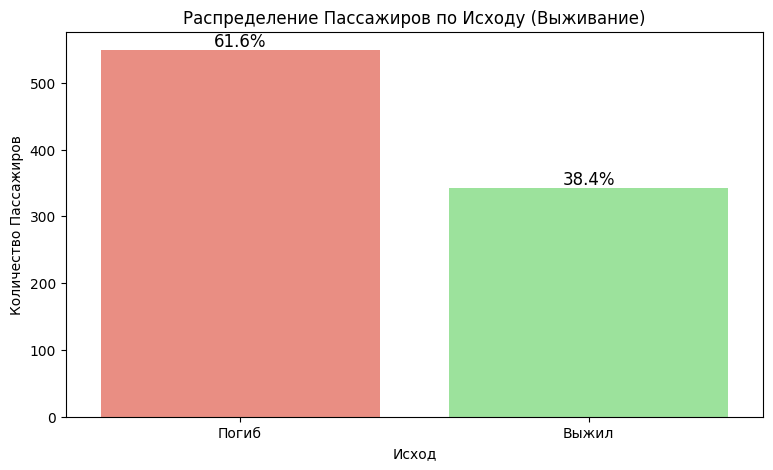

In [59]:
#График показывает соотношение погибших и выживших. Явный дисбаланс классов: большинство пассажиров 61% погибло, выжило 38%.
plt.figure(figsize=(9, 5))
ax = sns.countplot(x='Survived', data=df, palette=['salmon', 'lightgreen'])
plt.title('Распределение Пассажиров по Исходу (Выживание)')
plt.xlabel('Исход')
plt.ylabel('Количество Пассажиров')

plt.xticks(ticks=[0, 1], labels=['Погиб', 'Выжил'])

total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), size=12, ha='center', va='bottom')

plt.show()

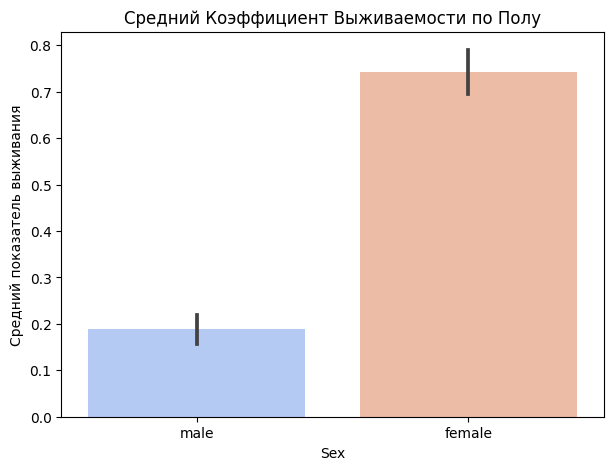

In [60]:
# График показывающий влияние пола на выживаемость
plt.figure(figsize=(7, 5))
sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm')
plt.title('Средний Коэффициент Выживаемости по Полу')
plt.ylabel('Средний показатель выживания')
plt.show()

In [61]:
# Статистический метод: процент выживших по полу, с текстовыми метками
survival_sex_crosstab = pd.crosstab(df['Sex'], df['Survived'])
survival_sex_crosstab.columns = ['Погиб', 'Выжил'] # Переименовываем колонки
print("Распределение и процент выживших по полу:")
survival_sex_crosstab.div(survival_sex_crosstab.sum(axis=1), axis=0).mul(100)

Распределение и процент выживших по полу:


,Погиб,Выжил
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


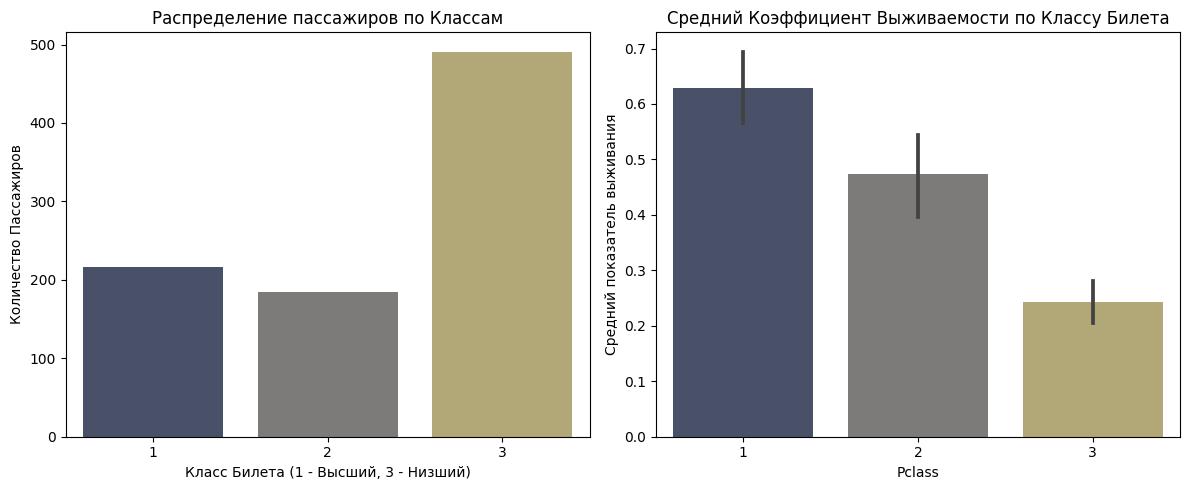

In [62]:
#график влияния класса каюты (PClass)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='Pclass', data=df, palette='cividis')
plt.title('Распределение пассажиров по Классам')
plt.xlabel('Класс Билета (1 - Высший, 3 - Низший)')
plt.ylabel('Количество Пассажиров')

plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=df, palette='cividis')
plt.title('Средний Коэффициент Выживаемости по Классу Билета')
plt.ylabel('Средний показатель выживания')

plt.tight_layout()
plt.show()

In [63]:
# Создание возрастных групп для более простого анализа
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Дети', 'Подростки', 'Молодые Взрослые', 'Взрослые', 'Пожилые']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

age_survival_rate = df.groupby('AgeGroup', observed=True)['Survived'].mean().mul(100)
print("Процент выживших по возрастным группам:")
age_survival_rate

Процент выживших по возрастным группам:


AgeGroup
Дети                57.971014
Подростки           42.857143
Молодые Взрослые    35.327103
Взрослые            40.000000
Пожилые             22.727273
Name: Survived, dtype: float64

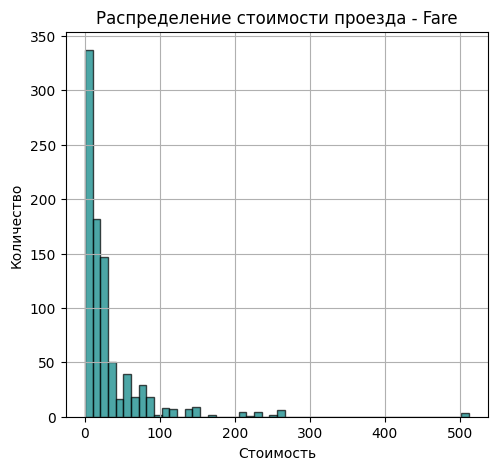

In [64]:
# Гистограмма показывает, что большинство пассажиров путешествовало по дешевым билетам
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['Fare'].hist(bins=50, alpha=0.7, color='teal', edgecolor='black')
plt.title('Распределение стоимости проезда - Fare')
plt.xlabel('Стоимость')
plt.ylabel('Количество')

plt.show()

In [65]:
# Создание признака FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 

print("Распределение пассажиров по размеру семьи:")
df['FamilySize'].value_counts().sort_index()

Распределение пассажиров по размеру семьи:


FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

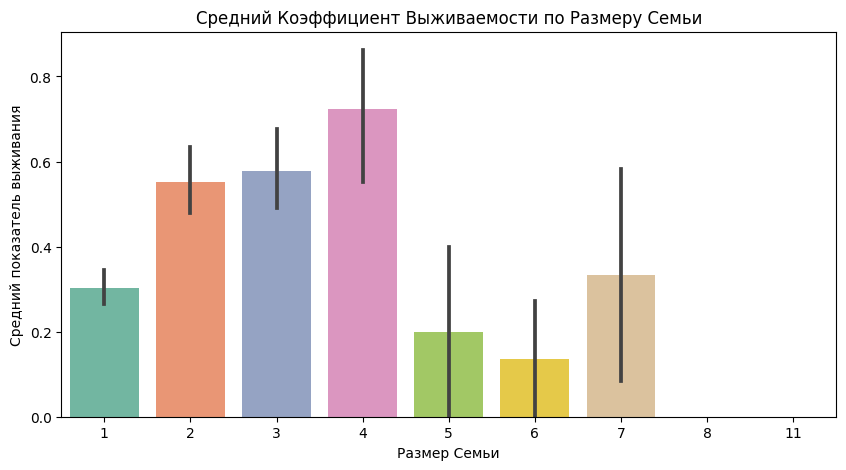

In [66]:
# График показывает нелинейную зависимость: одиночки и члены очень больших семей (5+ человек) погибали чаще.
# Наивысшие шансы на спасение имели небольшие семьи (2–4 человека)
plt.figure(figsize=(10, 5))
sns.barplot(x='FamilySize', y='Survived', data=df, palette='Set2')
plt.title('Средний Коэффициент Выживаемости по Размеру Семьи')
plt.xlabel('Размер Семьи')
plt.ylabel('Средний показатель выживания')
plt.show()

In [67]:
# Численное кодирование 'Sex' (Female=1, Male=0)
df['Sex_N'] = df['Sex'].map({'male': 0, 'female': 1})

# Выбор числовых колонок для расчета
numeric_cols = ['Survived', 'Pclass', 'Sex_N', 'Age', 'Fare', 'FamilySize']
corr_df = df[numeric_cols].copy()

# Расчет корреляции и сортировка по 'Survived'
correlation_matrix = corr_df.corr()
target_correlations = correlation_matrix['Survived'].sort_values(ascending=False)

print("Финальная корреляция признаков с Выживанием (Survived):")
target_correlations

Финальная корреляция признаков с Выживанием (Survived):


Survived      1.000000
Sex_N         0.543351
Fare          0.257307
FamilySize    0.016639
Age          -0.064910
Pclass       -0.338481
Name: Survived, dtype: float64

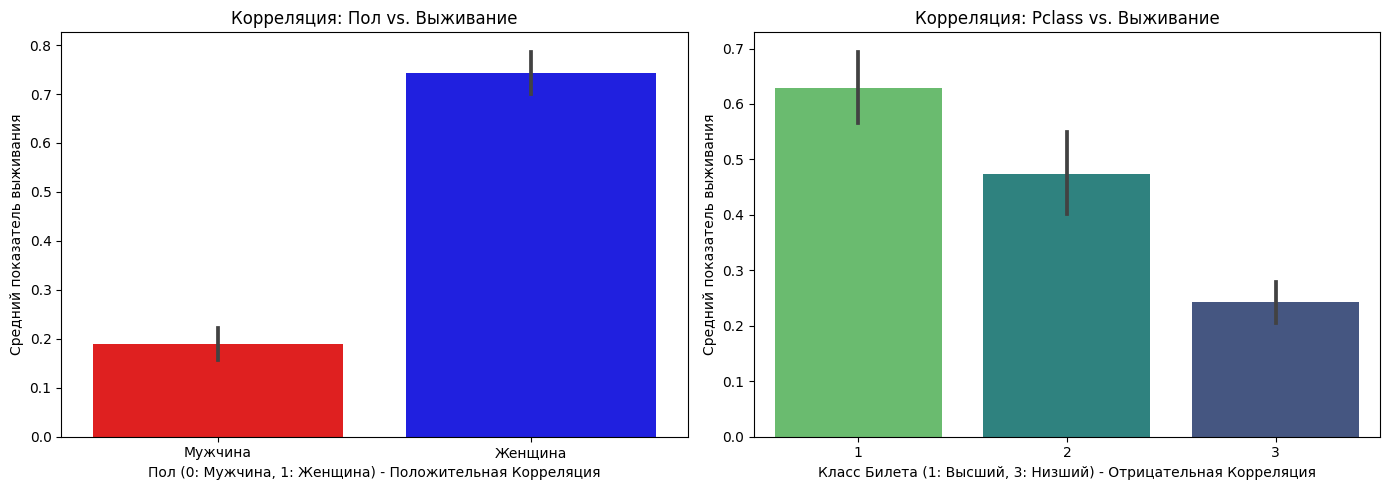

In [68]:
plt.figure(figsize=(14, 5))

# График 1: Положительная корреляция (Пол)
plt.subplot(1, 2, 1)
sns.barplot(x='Sex_N', y='Survived', data=corr_df, palette=['red', 'blue'])
plt.title('Корреляция: Пол vs. Выживание')
plt.xlabel('Пол (0: Мужчина, 1: Женщина) - Положительная Корреляция')
plt.ylabel('Средний показатель выживания')
plt.xticks(ticks=[0, 1], labels=['Мужчина', 'Женщина'])


# График 2: Отрицательная корреляция (Класс)
plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=corr_df, palette='viridis_r') # invert colors for visual clarity
plt.title('Корреляция: Pclass vs. Выживание')
plt.xlabel('Класс Билета (1: Высший, 3: Низший) - Отрицательная Корреляция')
plt.ylabel('Средний показатель выживания')

plt.tight_layout()
plt.show()

Данные готовы к обучению. Итоговые колонки:
['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_Code', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


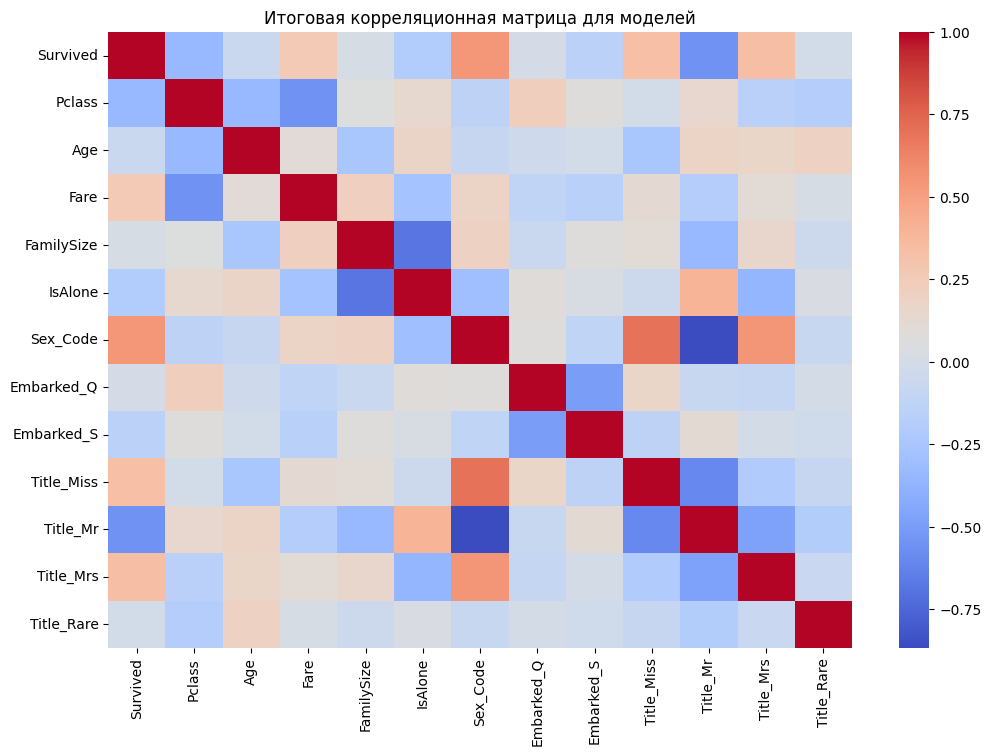

In [69]:
# 1. Достаем Титул из имени (Mr, Mrs и т.д.)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Группируем редкие титулы в одну кучу "Rare", исправляем опечатки
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 2. Признак "Одиночка", используем FamilySize
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 3. Кодируем пол
df['Sex_Code'] = df['Sex'].map({'male': 0, 'female': 1})

# 4. One-Hot Encoding для Порта (Embarked) и Титула (Title)
df_encoded = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)

# 5. Удаляем мусор и текстовые колонки, которые модели не понимают
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Sex', 'SibSp', 'Parch']

# Проверяем есть ли AgeGroup
if 'AgeGroup' in df_encoded.columns:
    cols_to_drop.append('AgeGroup')
if 'Sex_N' in df_encoded.columns: 
    cols_to_drop.append('Sex_N')

# Создаем финальный датафрейм для обучения
df_model = df_encoded.drop(cols_to_drop, axis=1)

print("Данные готовы к обучению. Итоговые колонки:")
print(df_model.columns.tolist())

# Корреляция на готовых данных
plt.figure(figsize=(12, 8))
sns.heatmap(df_model.corr(), annot=False, cmap='coolwarm')
plt.title("Итоговая корреляционная матрица для моделей")
plt.show()

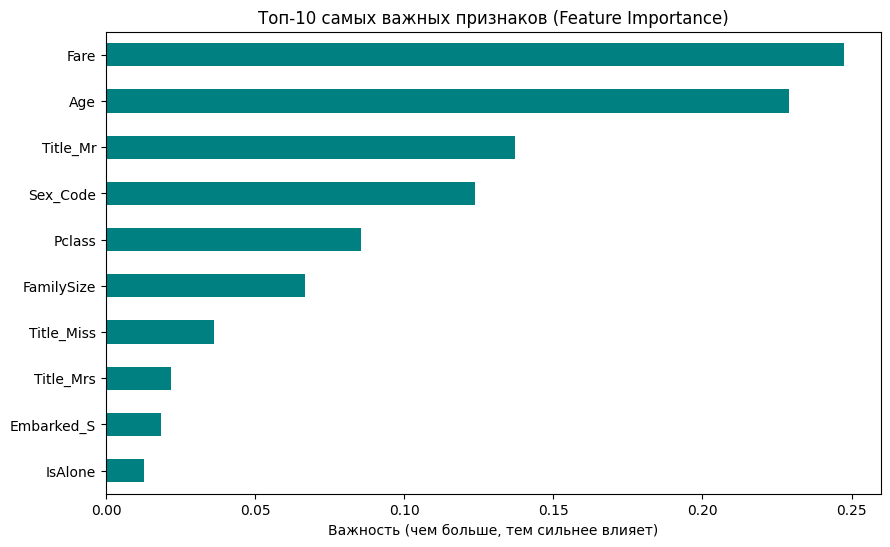

Самые важные признаки:
 Fare        0.247479
Age         0.228942
Title_Mr    0.137148
Sex_Code    0.123615
Pclass      0.085364
dtype: float64


In [70]:
# Разделяем данные на X (признаки) и y (цель - выжил или нет)
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

# Создаем и обучаем простую модель, чтобы она оценила важность
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y)

# Создаем табличку важности и сортируем её
feat_importances = pd.Series(rf_temp.feature_importances_, index=X.columns)

# Рисуем график Топ-10 самых важных признаков
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Топ-10 самых важных признаков (Feature Importance)')
plt.xlabel('Важность (чем больше, тем сильнее влияет)')
plt.show()

print("Самые важные признаки:\n", feat_importances.nlargest(5))

In [ ]:
# Настройка 5 фолдов
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Список моделей
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression()),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "Neural Network": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42))
}

print("Результаты кросс-валидации (Accuracy):")
print("-" * 40)

results = {}

for name, model in models.items():
    # Считаем точность
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} (std: {scores.std():.4f})")

# Итог
best_model = max(results, key=results.get)
print("-" * 40)
print(f"Лучшая модель: {best_model} с точностью {results[best_model]:.4f}")

Результаты кросс-валидации (Accuracy):
----------------------------------------
Logistic Regression: 0.8294 (std: 0.0077)
Decision Tree: 0.8227 (std: 0.0201)
Gradient Boosting: 0.8451 (std: 0.0100)
Neural Network: 0.8272 (std: 0.0044)
----------------------------------------
Лучшая модель: Gradient Boosting с точностью 0.8451


## Итоговый вывод

1. **Подготовка данных:** Пропуски в возрасте заполнены медианой. Каюта удалена из-за нехватки данных.
2. **Признаки:** Добавлены признаки `Title`, `FamilySize` и `IsAlone`. Пол и порт закодированы в числа.
3. **Важность:** Анализ показал, что пол, возраст и стоимость билета являются самыми важными факторами выживания.
4. **Модели:** В сравнении 4-х семейств моделей (Линейные, Деревья, Бустинг, Нейросети) на кросс-валидации победил **Gradient Boosting**, показав наилучшую точность - 0.84. Высший результат.
   